# Medical Imaging Machine Learning Project - Sandra Kayirangwa

- **Body part:** Eye/Retina
- **Imaging modality:** Fundus photograph
- **Problem type:** Image classification
- **Target classes:** Diabetic retinopathy severity levels
- **Dataset:** APTOS 2019 Blindness Detection
- **Dataset source:** Kaggle
- **Date:** September 13, 2026

 **Real world question:** Can a machine-learning model classify retinal photographs according to the severity of diabetic retinopathy?

I am building a medical image classification project using the APTOS 2019 retinal fundus image dataset. The project will train a machine learning model to classify retinal images according to diabetic retinopathy severity, document the complete ML process, save the trained model and create a Streamlit portal that allows a user to upload an unseen retinal image and receive the model's actual prediction and confidence.

In [1]:
import pandas as pd

df = pd.read_csv("Medical/train.csv")
df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [2]:
df["diagnosis"].value_counts().sort_index()

diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

### Dataset Source

The dataset used in this project is the APTOS 2019 Blindness Detection dataset. It contains 3,662 labelled retinal fundus images classified into five diabetic retinopathy severity levels (0–4).

**Source:** Kaggle APTOS 2019 Blindness Detection  
**Access date:** September 13, 2026  
**Usage terms:** The dataset is subject to the Kaggle competition rules.

# A1. Problem definition & Clinical framing

## Problem Definition

This project is a classification task using retinal fundus photographs from the APTOS 2019 Blindness Detection dataset. The aim is to develop a machine learning model that classifies retinal images into five diabetic retinopathy severity levels.

The five target classes are:

- **0 — No diabetic retinopathy**
- **1 — Mild diabetic retinopathy**
- **2 — Moderate diabetic retinopathy**
- **3 — Severe diabetic retinopathy**
- **4 — Proliferative diabetic retinopathy**

For example, if the model predicts class 2 for an image this means that the model predicts the image belongs to the moderate diabetic retinopathy category.

## Clinical Framing

The question this project explores is whether a machine learning model can classify retinal fundus photographs according to diabetic retinopathy severity.

This project is a student coursework prototype and is not a medical diagnostic tool. It should not be used to make clinical decisions or replace assessment by a qualified healthcare professional.

The model is designed for retinal fundus photographs similar to those in the training dataset. Images that differ substantially from the training data may produce unreliable predictions.

In [3]:
import os
from sklearn.model_selection import train_test_split

os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import tensorflow as tf

I0000 00:00:1789449091.522575   93128 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789449092.619192   93128 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [4]:
image_files = os.listdir("Medical/train_images")

image_files[:10]

['65e120143825.png',
 '7ef5ff774a48.png',
 '6d6fcf49e515.png',
 '6cee2e148520.png',
 '274f5029189b.png',
 '7247a2c97f71.png',
 '0afbeeef0ff7.png',
 '3cdef7c591cc.png',
 '2209daf71aab.png',
 '08c17a2d95b7.png']

In [5]:
from PIL import Image
import pandas as pd

image_info = []

for filename in image_files:
    image_path = os.path.join("Medical", "train_images", filename)

    try:
        with Image.open(image_path) as img:
            image_info.append({
                "filename": filename,
                "format": img.format,
                "width": img.width,
                "height": img.height,
                "mode": img.mode
            })
    except Exception as e:
        print("Could not read:", filename)

image_info_df = pd.DataFrame(image_info)

image_info_df.head()

,filename,format,width,height,mode
0,65e120143825.png,PNG,2416,1736,RGB
1,7ef5ff774a48.png,PNG,819,614,RGB
2,6d6fcf49e515.png,PNG,1050,1050,RGB
3,6cee2e148520.png,PNG,2588,1958,RGB
4,274f5029189b.png,PNG,2416,1736,RGB


In [6]:
image_info_df["format"].value_counts()

format
PNG    3662
Name: count, dtype: int64

In [7]:
image_info_df.groupby(
    ["width", "height"]
).size().sort_values(ascending=False).head(10)

width  height
1050   1050      974
2416   1736      638
2588   1958      533
3216   2136      410
2048   1536      351
819    614       287
3388   2588      141
1504   1000       92
1844   1226       61
4288   2848       52
dtype: int64

In [8]:
image_info_df["mode"].value_counts()

mode
RGB    3662
Name: count, dtype: int64

In [9]:
csv_ids = set(df["id_code"].astype(str))

image_ids = {
    os.path.splitext(filename)[0]
    for filename in image_files
}

missing_images = csv_ids - image_ids
extra_images = image_ids - csv_ids

print("Images listed in CSV:", len(csv_ids))
print("Images found in folder:", len(image_ids))
print("Missing images:", len(missing_images))
print("Extra images:", len(extra_images))

Images listed in CSV: 3662
Images found in folder: 3662
Missing images: 0
Extra images: 0


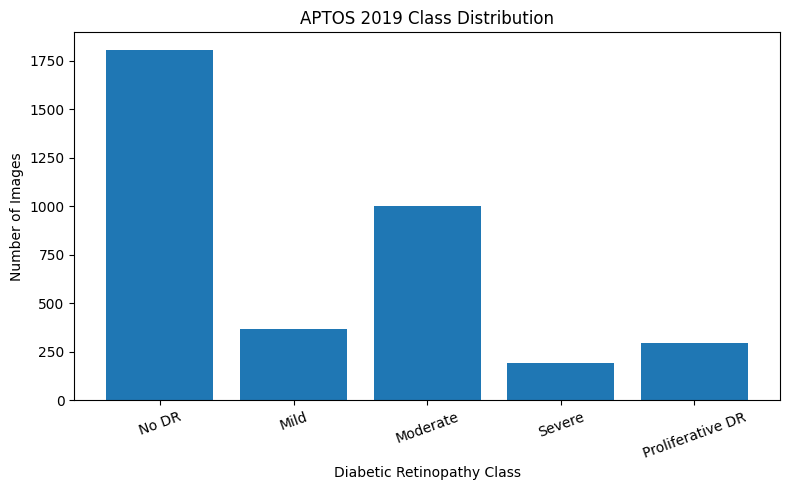

In [10]:
import matplotlib.pyplot as plt

class_counts = df["diagnosis"].value_counts().sort_index()

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

plt.figure(figsize=(8, 5))

plt.bar(class_names, class_counts.values)

plt.xlabel("Diabetic Retinopathy Class")
plt.ylabel("Number of Images")
plt.title("APTOS 2019 Class Distribution")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [11]:
class_percentages = (
    df["diagnosis"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

for class_number, percentage in class_percentages.items():
    print(f"Class {class_number}: {percentage:.2f}%")

Class 0: 49.29%
Class 1: 10.10%
Class 2: 27.28%
Class 3: 5.27%
Class 4: 8.06%


# A2. Dataset Documentation

## Class Distribution

The dataset contains five diabetic retinopathy severity classes:

| Diagnosis | Class | Number of Images |
|---:|---|---:|
| 0 | No diabetic retinopathy | 1,805 |
| 1 | Mild diabetic retinopathy | 370 |
| 2 | Moderate diabetic retinopathy | 999 |
| 3 | Severe diabetic retinopathy | 193 |
| 4 | Proliferative diabetic retinopathy | 295 |
| **Total** | | **3,662** |

The classes are not evenly distributed. Class 0 (No diabetic retinopathy) is the largest class, while Class 3 (Severe diabetic retinopathy) is the smallest. This class imbalance is important because the model may have more training examples for some severity levels than others.

## Image Characteristics

The dataset consists of colour retinal fundus photographs. The image inspection showed that **all 3,662 images are PNG files and use RGB colour mode**.

The images do not all have the same dimensions. The most common dimensions found in the dataset were:

| Width | Height | Number of Images |
|---:|---:|---:|
| 1050 | 1050 | 974 |
| 2416 | 1736 | 638 |
| 2588 | 1958 | 533 |
| 3216 | 2136 | 410 |
| 2048 | 1536 | 351 |

Other image dimensions are also present. Therefore, the images have different resolutions and will need to be resized to a consistent input size during data preparation.

The APTOS dataset documentation also notes that retinal images may contain artifacts and may be out of focus, underexposed, or overexposed. The images were collected from multiple clinics using different cameras, creating variation in image appearance and acquisition conditions.

## Labelling

Each image is assigned a diagnosis value from **0 to 4**. The labels represent the severity of diabetic retinopathy:

- **0 : No diabetic retinopathy**
- **1 : Mild diabetic retinopathy**
- **2 : Moderate diabetic retinopathy**
- **3 : Severe diabetic retinopathy**
- **4 : Proliferative diabetic retinopathy**

The diagnosis labels are provided in the `train.csv` file and are used as the target values for the classification model.

## Dataset Limitations

The dataset has a noticeable class imbalance. Some severity categories contain substantially more images than others, particularly the No DR and Moderate DR classes compared with the Severe DR class.

There is also variation in image resolution and image quality. Differences in cameras, clinics, exposure, focus and other image characteristics may make classification more difficult.

These limitations may affect how well the trained model performs, particularly when it encounters retinal images that differ from those represented in the training dataset.

## Dataset Usage Terms

The dataset is provided through Kaggle and is subject to the **APTOS 2019 Blindness Detection competition rules**. The dataset is being used in this project for academic coursework.

# A3. Data Preparation & Splitting

## Data Cleaning

The dataset was checked to ensure that the image files listed in `train.csv` were available in the training image folder. All 3,662 image records had corresponding image files, so no images needed to be removed because of missing files.

The images were also inspected during dataset documentation. All images were found to be PNG files and RGB colour images.

In [12]:
image_files = os.listdir("Medical/train_images")

image_file_set = set(image_files)

df["image_filename"] = df["id_code"] + ".png"
df["image_exists"] = df["image_filename"].isin(image_file_set)

print("Images listed in CSV:", len(df))
print("Images found in folder:", df["image_exists"].sum())
print("Missing images:", (~df["image_exists"]).sum())
print("Extra images:", len(image_file_set - set(df["image_filename"])))

Images listed in CSV: 3662
Images found in folder: 3662
Missing images: 0
Extra images: 0


In [13]:
df["image_path"] = df["image_filename"].apply(
    lambda x: os.path.join("Medical/train_images", x)
)

df = df.drop(columns=["image_exists"])

df.head()

,id_code,diagnosis,image_filename,image_path
0,000c1434d8d7,2,000c1434d8d7.png,Medical/train_images/000c1434d8d7.png
1,001639a390f0,4,001639a390f0.png,Medical/train_images/001639a390f0.png
2,0024cdab0c1e,1,0024cdab0c1e.png,Medical/train_images/0024cdab0c1e.png
3,002c21358ce6,0,002c21358ce6.png,Medical/train_images/002c21358ce6.png
4,005b95c28852,0,005b95c28852.png,Medical/train_images/005b95c28852.png


## Resizing

The original retinal images have different dimensions. Since the machine-learning model requires a consistent input size, all images will be resized to **224 × 224 pixels**.

This resizing is applied when the images are loaded by the image generators.

## Normalization

Because the project uses a pretrained MobileNetV2 model, the images will be processed using the MobileNetV2 preprocessing function.

This converts the original RGB pixel values from the range 0–255 to the range expected by the pretrained model, approximately -1 to 1.
The same preprocessing will be used for the training, validation, test and Streamlit prediction images.

## Data Augmentation

Data augmentation will be applied only to the training images. Small rotations, horizontal flipping and zooming will be used to introduce reasonable variation into the training data and help the model generalize.

No augmentation will be applied to the validation or test sets because these sets should be used to evaluate the model without artificially modifying the images.

In [14]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1
)

val_test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Training augmentation enabled")
print("Validation/test augmentation disabled")

Image size: (224, 224)
Batch size: 32
Training augmentation enabled
Validation/test augmentation disabled


## Dataset Splitting

The dataset was divided into training, validation and test sets using a stratified split. Stratification was used to maintain a similar representation of the five diabetic retinopathy classes across the three subsets.

The final split is approximately 70% training, 15% validation and 15% testing.

In [15]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df["diagnosis"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["diagnosis"]
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 2563
Validation images: 549
Test images: 550


In [16]:
print("Training class distribution:")
print(train_df["diagnosis"].value_counts().sort_index())

print("\nValidation class distribution:")
print(val_df["diagnosis"].value_counts().sort_index())

print("\nTest class distribution:")
print(test_df["diagnosis"].value_counts().sort_index())

Training class distribution:
diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

Validation class distribution:
diagnosis
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

Test class distribution:
diagnosis
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


## Image Data Generators

Image data generators are used to load the images from the training, validation and test datasets and apply the required preprocessing.

The training generator applies MobileNetV2 preprocessing as well as data augmentation such as small rotations, horizontal flipping and zooming. This provides variation in the training images and can help the model generalize.

The validation and test generators apply only the MobileNetV2 preprocessing. No augmentation is applied to these images because they are used to evaluate the model on data that has not been artificially modified.

The data is loaded in batches of 32 images, and all images are resized to 224 × 224 pixels before being passed to the model.


In [17]:
train_df["diagnosis"] = train_df["diagnosis"].astype(str)
val_df["diagnosis"] = val_df["diagnosis"].astype(str)
test_df["diagnosis"] = test_df["diagnosis"].astype(str)

class_labels = ["0", "1", "2", "3", "4"]

train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="diagnosis",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    classes=class_labels,
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="diagnosis",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    classes=class_labels,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="diagnosis",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    classes=class_labels,
    shuffle=False
)

Found 2563 validated image filenames belonging to 5 classes.
Found 549 validated image filenames belonging to 5 classes.
Found 550 validated image filenames belonging to 5 classes.


## Leakage and Overlap

The image identifiers were checked to ensure that no image appears in more than one dataset split.

The overlap checks produced the following results:

- Training/Validation overlap: **0**
- Training/Test overlap: **0**
- Validation/Test overlap: **0**

Therefore, there is no overlap between the image identifiers in the three splits.

Patient-level or source-level overlap could not be independently verified because the available dataset information does not provide patient identifiers. Therefore, this project does not claim to have verified patient-level separation.

In [18]:
train_ids = set(train_df["id_code"])
val_ids = set(val_df["id_code"])
test_ids = set(test_df["id_code"])

print("Train/Validation overlap:", len(train_ids & val_ids))
print("Train/Test overlap:", len(train_ids & test_ids))
print("Validation/Test overlap:", len(val_ids & test_ids))

Train/Validation overlap: 0
Train/Test overlap: 0
Validation/Test overlap: 0


# A4. Model Architecture & Justification

## Model Architecture

The model used for this project is **MobileNetV2** with transfer learning.

MobileNetV2 is a convolutional neural network (CNN) designed for image classification while using fewer computational resources than many larger CNN architectures.

A pretrained MobileNetV2 model will be used as the base model. Its original classification layer will be removed and replaced with a new classification layer for the five diabetic retinopathy severity classes in this project.

The model will therefore produce one prediction for each of the five classes:

- Class 0: No diabetic retinopathy
- Class 1: Mild diabetic retinopathy
- Class 2: Moderate diabetic retinopathy
- Class 3: Severe diabetic retinopathy
- Class 4: Proliferative diabetic retinopathy

## Why This Architecture Was Chosen

MobileNetV2 was selected because the project is an image classification task involving retinal fundus photographs.

Using a pretrained image model allows the project to make use of features learned from a large image dataset instead of training a complete CNN from the beginning. This is useful for this project because the APTOS dataset contains a relatively limited number of labelled images compared with large image datasets.

MobileNetV2 is also relatively lightweight, which is useful because the final model will be used in a Streamlit application where an uploaded retinal image needs to be processed and classified.

## Model Input and Output

The model will receive a colour retinal fundus image resized to:

**224 × 224 × 3**

The three channels represent the RGB colour channels.

The final output will contain probabilities for the five diabetic retinopathy classes. The class with the highest probability will be used as the model's predicted class.

## Main Training Settings

The planned training settings are:

- **Input size:** 224 × 224 pixels
- **Batch size:** 32
- **Number of classes:** 5
- **Optimizer:** Adam
- **Loss function:** Sparse categorical cross-entropy
- **Learning rate:** 0.0001

The exact number of training epochs will be determined during the training process.

## Alternative Approaches

A custom CNN could have been built from the beginning, but transfer learning was selected instead because it can provide useful image features without requiring a very large labelled dataset.

A larger and more computationally demanding architecture was also not selected because the project needs to produce a practical coursework prototype and a lightweight Streamlit application.

In [19]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(5, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[early_stopping]
)

Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.5076 - loss: 1.3378 - val_accuracy: 0.5865 - val_loss: 1.1462
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 262s 3s/step - accuracy: 0.6110 - loss: 1.1281 - val_accuracy: 0.6448 - val_loss: 1.0242
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 256s 3s/step - accuracy: 0.6528 - loss: 1.0130 - val_accuracy: 0.6648 - val_loss: 0.9527
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.6563 - loss: 0.9532 - val_accuracy: 0.6831 - val_loss: 0.9017
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 259s 3s/step - accuracy: 0.6808 - loss: 0.8853 - val_accuracy: 0.6995 - val_loss: 0.8618
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.6929 - loss: 0.8677 - val_accuracy: 0.6958 - val_loss: 0.8438
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 254s 3s/step - accuracy: 0.7078 - loss: 0.8245 - val_accuracy: 0.7140 - val_loss: 0.8093
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.7054 - loss: 0.8041 - val_accuracy: 0.7122 - v

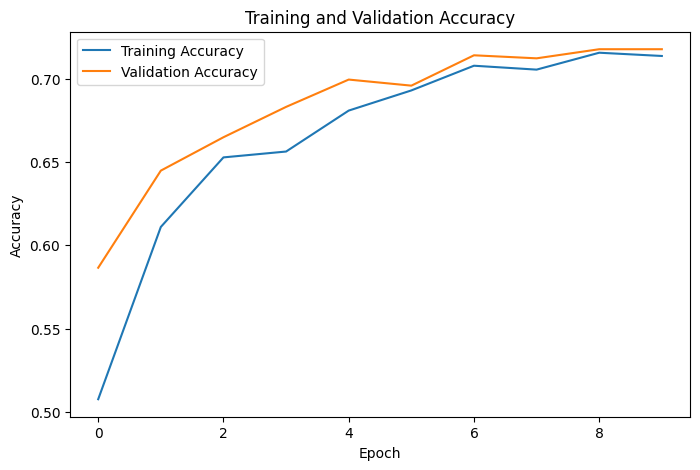

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

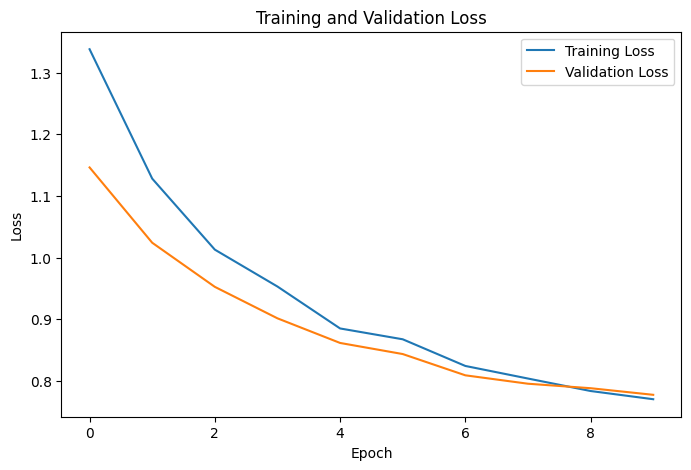

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

## Training Results

The MobileNetV2 model was trained for 10 epochs using the training dataset and evaluated on the validation dataset after each epoch.

Training accuracy increased from 50.76% in the first epoch to 71.36% in the final epoch. Validation accuracy increased from 58.65% to 71.77%.

Training loss decreased from 1.3378 to 0.7706, while validation loss decreased from 1.1462 to 0.7778.

The training and validation results remained relatively close throughout training, and the validation loss continued to decrease by the final epoch. This suggests that there was no strong evidence of severe overfitting during these 10 epochs.

# A6. Model Evaluation

The trained model is evaluated on the test dataset, which was not used during model training. Accuracy, precision, recall and F1-score are used to assess the model's classification performance across the five diabetic retinopathy severity classes.

In [25]:
test_generator.reset()

predictions = model.predict(test_generator)

y_pred = predictions.argmax(axis=1)

y_true = test_generator.classes

print("Number of test images:", len(y_true))
print("Number of predictions:", len(y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step
Number of test images: 550
Number of predictions: 550


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7364
Precision: 0.7286
Recall:    0.7364
F1-score:  0.6845


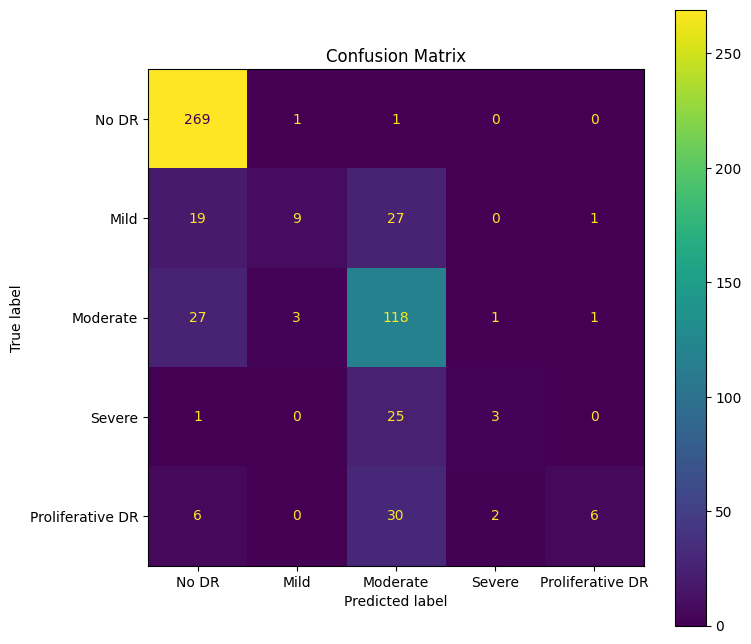

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative DR"
    ]
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")

plt.title("Confusion Matrix")
plt.show()


### Confusion Matrix Interpretation

The confusion matrix shows that the model performed best on the No DR class, correctly classifying 269 of 271 images. It also correctly classified 118 of 150 Moderate DR images.

The model struggled more with the less represented severity classes. For example, only 9 of 56 Mild DR images and 3 of 29 Severe DR images were classified correctly. Many Mild, Severe and Proliferative DR images were predicted as Moderate DR.

This shows that the model can distinguish No DR reasonably well, but has more difficulty separating the different stages of diabetic retinopathy, particularly the less represented classes.

In [29]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=[
        "No DR",
        "Mild",
        "Moderate",
        "Severe",
        "Proliferative DR"
    ],
    zero_division=0
))

                  precision    recall  f1-score   support

           No DR       0.84      0.99      0.91       271
            Mild       0.69      0.16      0.26        56
        Moderate       0.59      0.79      0.67       150
          Severe       0.50      0.10      0.17        29
Proliferative DR       0.75      0.14      0.23        44

        accuracy                           0.74       550
       macro avg       0.67      0.44      0.45       550
    weighted avg       0.73      0.74      0.68       550



### Per Class Evaluation

The classification report shows that the model performs best on the No DR class, with a recall of 0.99 and an F1-score of 0.91. The Moderate DR class also has relatively strong performance, with a recall of 0.79 and an F1-score of 0.67.

Performance is substantially lower for Mild, Severe and Proliferative DR. Their recall values are 0.16, 0.10 and 0.14 respectively. This means that many images belonging to these classes were classified as another severity level. The lower performance on these classes is consistent with the class imbalance in the dataset and shows that overall accuracy alone does not fully describe the model's performance.

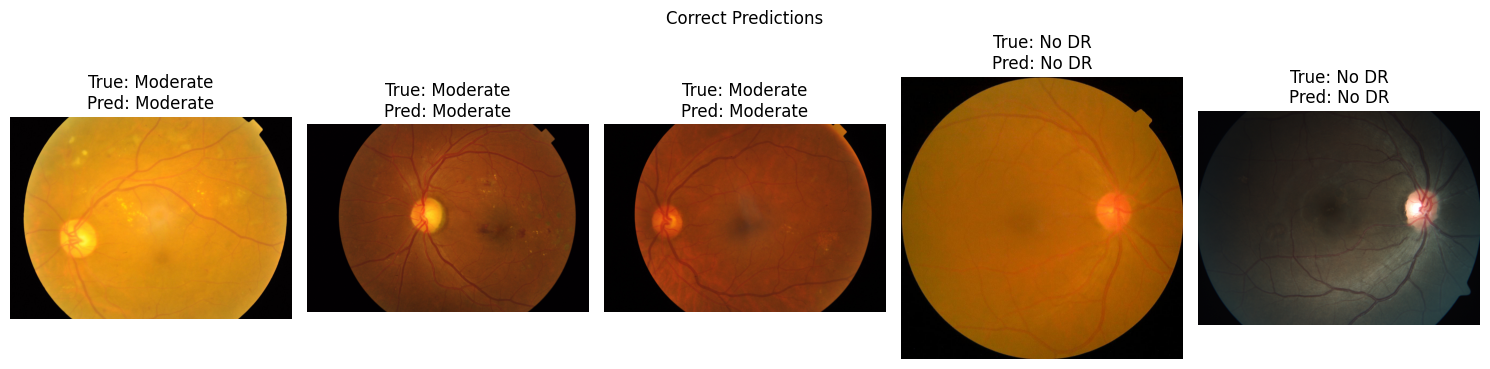

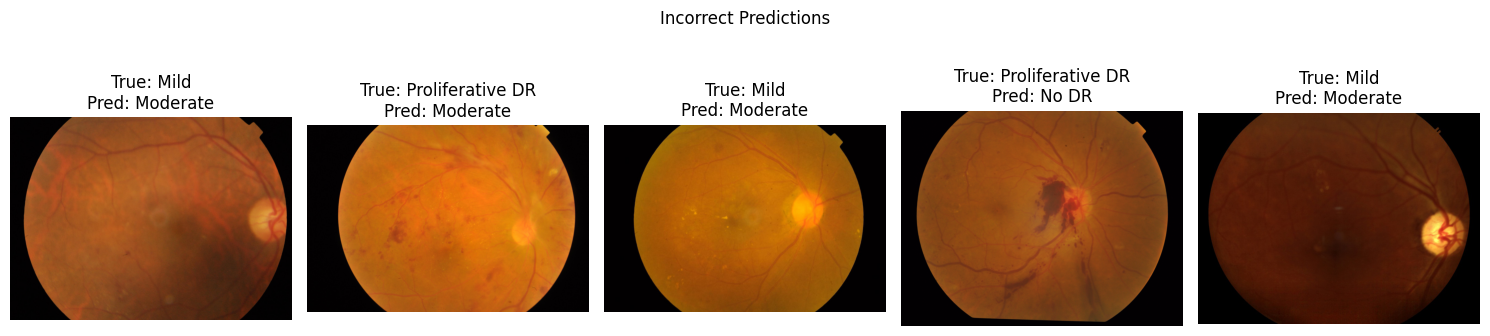

In [30]:
import numpy as np
import matplotlib.pyplot as plt

class_names = [
    "No DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative DR"
]

correct_indices = np.where(y_true == y_pred)[0]
incorrect_indices = np.where(y_true != y_pred)[0]

def show_examples(indices, title, n=5):
    n = min(n, len(indices))

    plt.figure(figsize=(15, 4))

    for i, idx in enumerate(indices[:n]):
        img = plt.imread(test_df.iloc[idx]["image_path"])

        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"True: {class_names[y_true[idx]]}\n"
            f"Pred: {class_names[y_pred[idx]]}"
        )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(
    correct_indices,
    "Correct Predictions",
    n=5
)

show_examples(
    incorrect_indices,
    "Incorrect Predictions",
    n=5
)

### Correct and Incorrect Prediction Examples

The model produced several correct predictions, particularly for images with No DR and Moderate DR. However, the incorrect examples show that the model often confuses different stages of diabetic retinopathy.

The main difficulty was distinguishing Mild, Severe and Proliferative DR from Moderate DR. This is consistent with the confusion matrix and per-class evaluation, where these classes had much lower recall. These errors show that the model's predictions should not be treated as a diagnosis.

# A7. Model Saving and Reproducibility

The trained MobileNetV2 model is saved so that it can be loaded later by the Streamlit application. The same image size and preprocessing used during testing will be used when making predictions in the application.

In [32]:
print("TensorFlow version:", tf.__version__)

model.save("aptos_mobilenetv2.keras")

print("Model saved successfully as aptos_mobilenetv2.keras")

TensorFlow version: 2.21.0
Model saved successfully as aptos_mobilenetv2.keras


### Saved Model Details

The trained model was saved in Keras format as `aptos_mobilenetv2.keras` using TensorFlow 2.21.0.

The preprocessing used for the model is:
- Images are resized to 224 × 224 pixels.
- MobileNetV2 `preprocess_input` normalization is applied.
- No data augmentation is applied during inference.

The Streamlit application will use the same preprocessing so that images are prepared consistently with the training and evaluation pipeline.

# A8. Limitations, Ethics & Next Steps

## Limitations and Bias

The dataset has a noticeable class imbalance, with many more images in the No DR and Moderate DR classes than in the Severe DR class. This may affect the model's ability to learn the less represented severity levels.

The retinal images also come from different sources and can vary in focus, exposure, resolution and image quality. Because of this, the model may not generalize equally well to images from different clinics, cameras or patient populations.

## False Positives and False Negatives

A false negative occurs when the model predicts a lower severity level than the actual diabetic retinopathy severity. In a real clinical setting, this could potentially result in a serious condition being overlooked or a referral being delayed.

A false positive occurs when the model predicts a higher severity level than the actual condition. This could lead to unnecessary further assessment, referrals or patient concern.

For these reasons, model predictions should not be treated as a diagnosis.

## Clinical Oversight

This project is a student coursework prototype and is not intended to replace a qualified healthcare professional. Any real world use of a diabetic retinopathy classification system would require appropriate clinical oversight and validation before it could be used to support patient care.

## What Would Be Needed for Real-World Trust

A real clinical system would require a larger and more diverse dataset, testing on data from different clinics and imaging devices, independent external validation, careful evaluation of false positives and false negatives, and appropriate clinical and regulatory evaluation.

The model would also need to be monitored to ensure that its performance remains reliable when used on new patient populations and different image acquisition conditions.